<a href="https://colab.research.google.com/github/IbtisamSafi/MachineLearning/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# Load train and test data
try:
    train = pd.read_csv('train.csv')
    test = pd.read_csv('test.csv')

    print("Data loaded")

    # Show dataset shape
    print(train.shape)

    # Show first columns
    print(train.columns[:10])

except FileNotFoundError:
    print("train.csv or test.csv not found")

Data loaded
(1460, 81)
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities'],
      dtype='object')


In [36]:
# Display dataset information
train.info()

# Convert some text columns to category type to reduce memory usage
for col in train.select_dtypes(include=['object']):
    if train[col].nunique() < 10:
        train[col] = train[col].astype('category')

print("Done")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [46]:
# Data cleaning

# Columns where missing values mean the feature does not exist
none_cols = ['PoolQC', 'Alley', 'Fence', 'FireplaceQu', 'MiscFeature']

for col in none_cols:
    if col in train.columns:
        train[col] = train[col].fillna('None')
        test[col] = test[col].fillna('None')

# Apply log transformation to SalePrice
if 'SalePrice' in train.columns:
    train['SalePrice'] = np.log1p(train['SalePrice'])
    print("SalePrice updated")
# Outlier removal
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 12)].index)

SalePrice updated


In [50]:
# Feature Engineering
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']


Feature engineering and encoding completed successfully
Final shape after encoding: (1460, 290)


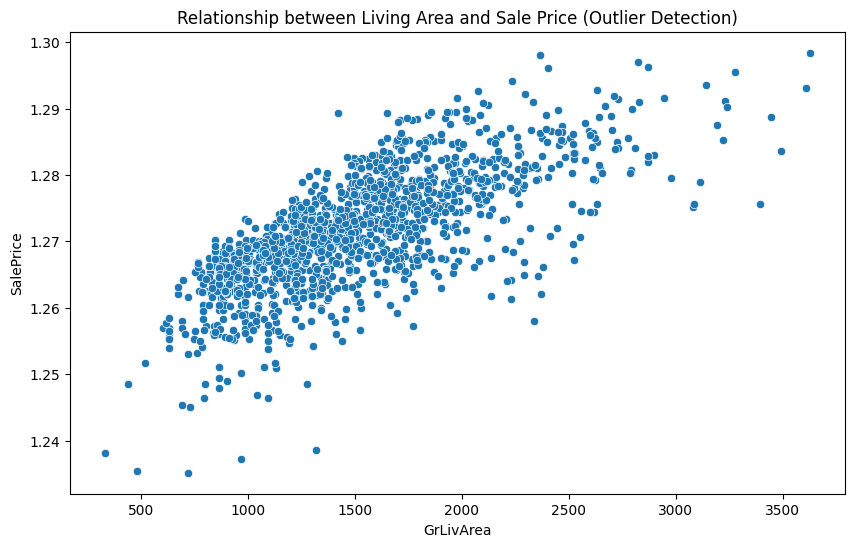

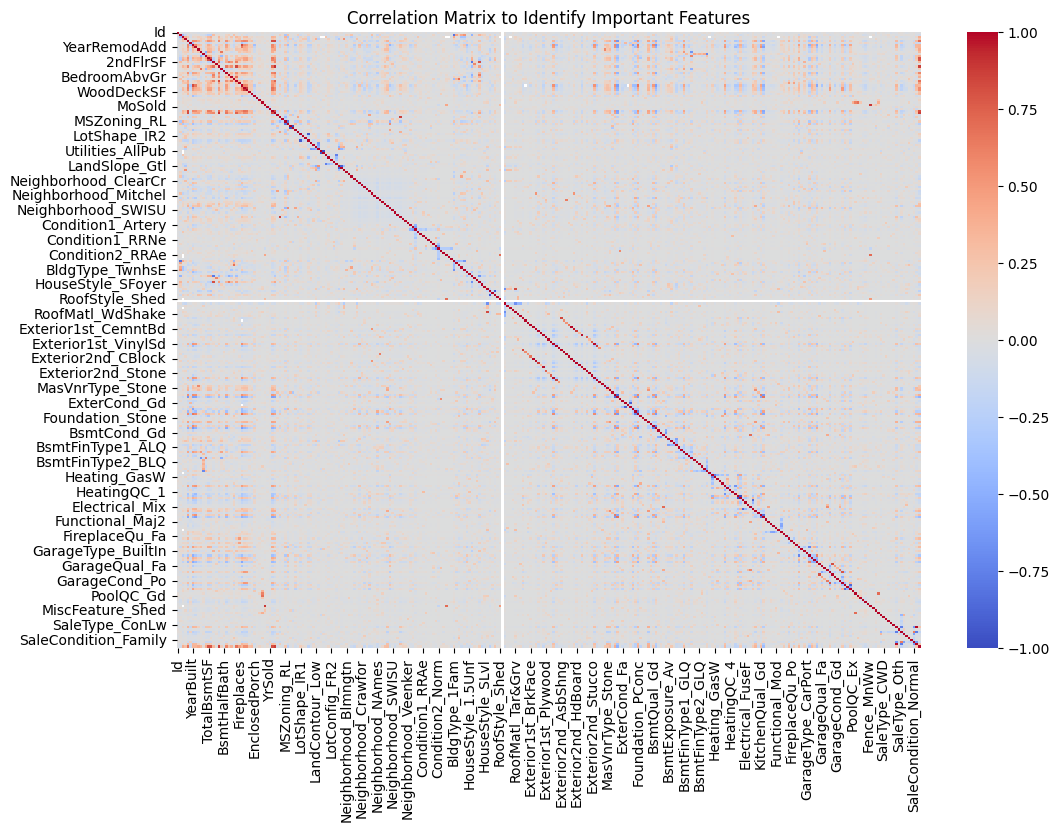

Total_Score    0.830933
TotalSF        0.816794
OverallQual    0.816149
GrLivArea      0.714215
GarageCars     0.679395
Name: SalePrice, dtype: float64


In [48]:
# 4. Exploratory Data Analysis (EDA Visuals)

# A- Detecting outliers visually
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train)
plt.title('Relationship between Living Area and Sale Price (Outlier Detection)')
plt.show()

# B- Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(train.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix to Identify Important Features')
plt.show()
# Top 5 correlated features with SalePrice
corr = train.corr(numeric_only=True)
top5 = corr['SalePrice'].sort_values(ascending=False)[1:6]
print(top5)